# 0050: original M6 vs locally scaled M6

The original log-price M6 is retained. Local scaling uses generic causal state features and no non-negative support clipping.

In [1]:
from pathlib import Path
import sys, matplotlib.pyplot as plt, numpy as np, pandas as pd
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src').exists()),None); sys.path.insert(0,str(ROOT/'src'))
from kf_forecasting.models.kf_enbpi import EnbPIConfig
from kf_forecasting.models.kf_out_of_time_enbpi import OutOfTimeEnbPIConfig,locally_scaled_from_fitted,run_out_of_time_enbpi
ALPHA=.05; SEED=2026; K=60

In [2]:
close=pd.read_csv(ROOT/'results/0050_six_method_original/0050_adjusted_close.csv',parse_dates=['Date']).set_index('Date').adjusted_close
train=close.loc['2020-01-01':'2024-12-31']; test=close.loc['2025-01-01':'2026-07-31']; full=pd.concat([train,test]); n=len(train)
fitted=run_out_of_time_enbpi(np.log(full.to_numpy()),n,config=OutOfTimeEnbPIConfig(base=EnbPIConfig(alpha=ALPHA,random_state=SEED)),model_name='0050 original M6',data_seed=SEED)
scaled=locally_scaled_from_fitted(fitted,test.index,neighbours=K,support_lower=None)
f=fitted.forecast
base=pd.DataFrame({'date':test.index,'method':'Original M6','truth':test.to_numpy(),'point':np.exp(f.point),'lower':np.exp(f.lower),'upper':np.exp(f.upper)})
local=scaled.predictions.copy(); local[['truth','point','lower','upper']]=np.exp(local[['truth','point','lower','upper']]); local=local.drop(columns='local_scale')

In [3]:
def metric(g):
 y,p,l,u=(g[c].to_numpy() for c in ['truth','point','lower','upper']); ml=y<l; mu=y>u
 return {'method':g.method.iloc[0],'coverage':np.mean((y>=l)&(y<=u)),'mean_width':np.mean(u-l),'median_width':np.median(u-l),'interval_score':np.mean(u-l+2/ALPHA*((l-y)*ml+(y-u)*mu)),'rmse':np.sqrt(np.mean((y-p)**2)),'mae':np.mean(abs(y-p)),'negative_lower_rate':np.mean(l<0)}
predictions=pd.concat([base,local],ignore_index=True); summary=pd.DataFrame([metric(g) for _,g in predictions.groupby('method',sort=False)]); summary.insert(1,'selected_window',[fitted.selected_residual_window,scaled.selected_window]); summary

,method,selected_window,coverage,mean_width,median_width,interval_score,rmse,mae,negative_lower_rate
0,Original M6,None,0.910995,3.710726,3.298317,7.360424,1.336881,0.881362,0.0
1,Local-scale M6,None,0.945026,4.369881,3.366966,6.307181,1.330979,0.877873,0.0


In [4]:
scaled.window_selection

,window,window_value,mean_interval_score,coverage,mean_width,n_validation_residuals,validation_start_position,selected
0,all,NaN,11.898375,0.942387,7.204151,243,364,True
1,300,300.0,12.367102,0.921811,6.923439,243,364,False
2,180,180.0,12.493426,0.925926,7.046285,243,364,False
3,120,120.0,12.513418,0.930041,6.918147,243,364,False
4,60,60.0,13.275239,0.897119,6.647486,243,364,False
5,24,24.0,14.069418,0.868313,5.938361,243,364,False


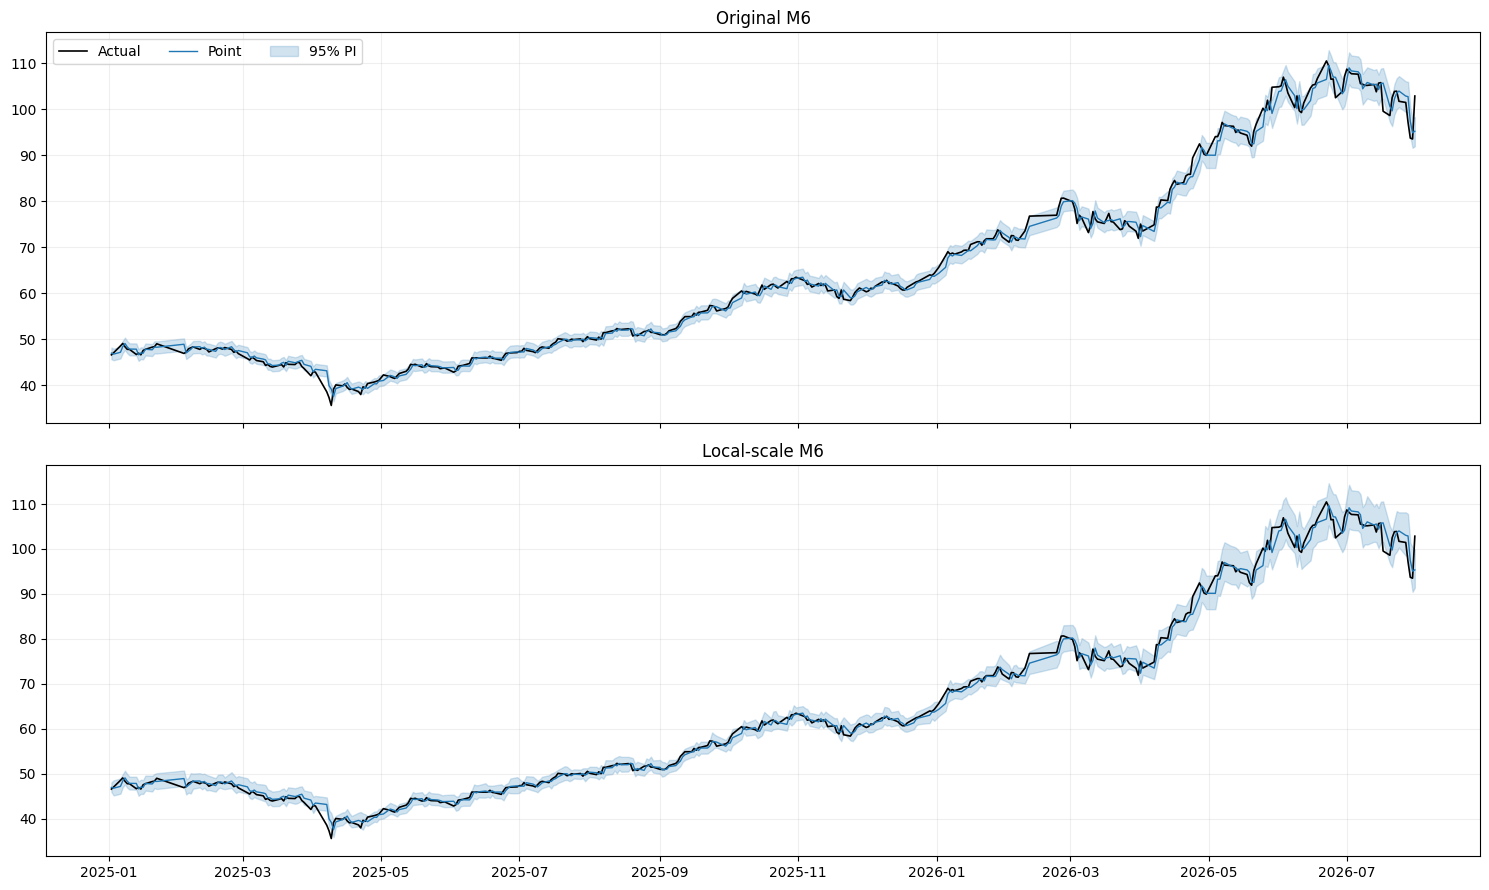

In [5]:
fig,axes=plt.subplots(2,1,figsize=(15,9),sharex=True)
for ax,(m,g) in zip(axes,predictions.groupby('method',sort=False)):
 ax.plot(g.date,g.truth,'k',lw=1.2,label='Actual'); ax.plot(g.date,g.point,color='tab:blue',lw=1,label='Point'); ax.fill_between(g.date,g.lower,g.upper,color='tab:blue',alpha=.2,label='95% PI'); ax.set_title(m); ax.grid(alpha=.2)
axes[0].legend(ncol=3); fig.tight_layout(); plt.show()